# GraphFlood: a large-scale hydrodynamics module for TopoToolbox

## Author

- Boris Gailleton, Université de Rennes, ([homepage](https://bgailleton.github.io/))

## Highlighted references

Gailleton, B., Steer, P., Davy, P., Schwanghart, W., and Bernard, T.: GraphFlood 1.0: an efficient algorithm to approximate 2D hydrodynamics for landscape evolution models, Earth Surf. Dynam., 12, 1295–1313, https://doi.org/10.5194/esurf-12-1295-2024, 2024.

## Audience

Experienced TopoToolbox users seeking to incorporate information on 2D hydrodynamics into their analyses.

## Introduction

Representing streams as networks of flow directions as in TopoToolbox's `FlowObject` and `StreamObject` is efficient for large-scale analysis but lacks detailed hydrodynamic information such as channel width, flow depth, velocity or shear stress that may be useful for investigations of landscape evolution and natural hazards. Recovering this information can be done by modeling the two or even three-dimensional flow of water over a landscape. However, the computational cost of solving the full shallow-water equations makes them unsuitable for large-scale exploratory analyses. To circumvent this, Gailleton et al. (2024) introduced GraphFlood, a numerical method that leverages graph theory and simplified shallow-water equations to compute large-scale, 2D steady-state flow conditions efficiently.

To illustrate how GraphFlood operates within TopoToolbox 3, we will simulate flow in the Saison watershed in the Western French Pyrenees. This watershed has a high variability in both relief and valley width, which demonstrates GraphFlood's versatility in estimating flow over different terrain.

First, we will import some libraries. The GraphFlood model setup and run and the longitudinal profiles are made using TopoToolbox, but a few extra packages are required for additional functionality. The only ones that are not distributed with TopoToolbox are [scikit-image](https://scikit-image.org/) and [cmocean](https://matplotlib.org/cmocean/) so to run this example, you will have to install those packages as well.

In [23]:
import os
import numpy as np
from scipy.ndimage import binary_dilation, distance_transform_edt
from scipy.spatial import KDTree
from scipy.signal import savgol_filter
from skimage.morphology import skeletonize

import topotoolbox as ttb

## DEM and flow routing

We load the pre-processed DEM (`dem_pp.tif`), fill sinks, and derive:
- `FlowObject` — D8 flow directions.
- `StreamObject` — channel network above a 10 000 cell flow accumulation threshold.
- Main trunk via `.trunk()`.
- Drainage area (m²) from `flow_accumulation`.

In [15]:
dem  = ttb.read_tif('./dem_pp.tif').fillsinks()
flob = ttb.FlowObject(dem)
stob = ttb.StreamObject(flob, threshold=1e4)
stob_trunk = ttb.StreamObject(flob, threshold=1e4).trunk()

drainage_area = flob.flow_accumulation(dem.cellsize)

Boundary conditions for GraphFlood are built from the NaN mask: interior valid pixels → 1 (active), pixels adjacent to the domain border → 3 (open outlet).

In [16]:
# GraphFlood boundary conditions
bcs = np.where(
    np.isnan(dem.z),
    0,
    np.where(binary_dilation(np.pad(np.isnan(dem.z), 1, constant_values=True))[1:-1, 1:-1], 3, 1)
).astype(np.uint8)

## GraphFlood simulations

We run steady-state GraphFlood for 3 rainfall intensities (mm/hr converted to m/s).
For each intensity the solver is warmed up with a decreasing-`dt` schedule (100 coarse steps) before the fine convergence loop (10 000 steps at `dt = 1e-3`).

While GraphFlood is fairly efficient, it can still take a long time to process a DEM. It may take several hours to complete this model run for all the rainfall intensities. The results are saved as `.npy` files, and the code below will skip the model runs if they already exist.

The following fields are saved for each intensity: 

- `hw`: water depth
- `Qw_i`: Input discharge
- `Qw_o`: Output discharge
- `Sw`: wetted area
- `q` : specific discharge
- `u` : flow velocity
- `tau`: shear stress

In [24]:
manning = 0.033
Ps_all  = np.array([10, 50, 100]) / 3_600_000  # mm/hr → m/s

for p in Ps_all:
    if os.path.exists(f'./hw_{p}.npy'):
        print(f'P={p:.2e} m/s — files found, skipping.')
        continue

    print(f'P={p:.2e} m/s — running simulation...')
    gfo = ttb.GFObject(dem, bcs, p, manning)

    # Warm-up: coarse time steps to accelerate initial transient
    for dt in np.linspace(1, 1e-3, 100):
        gfo.run_n_iterations(n_iterations=10, dt=dt)

    # Fine convergence
    gfo.run_n_iterations(n_iterations=10000, dt=1e-3)

    np.save(f'hw_{p}.npy',  gfo.hw)
    np.save(f'Qw_{p}.npy',  gfo.get_qvol_i())
    np.save(f'Qwo_{p}.npy', gfo.get_qvol_o())
    np.save(f'Sw_{p}.npy',  gfo.get_sw())
    np.save(f'q_{p}.npy',   gfo.get_q())
    np.save(f'u_{p}.npy',   gfo.get_u())
    np.save(f'tau_{p}.npy', gfo.compute_tau())
    print(f'  → saved.')

P=2.78e-06 m/s — files found, skipping.
P=1.39e-05 m/s — files found, skipping.
P=2.78e-05 m/s — files found, skipping.


**Note about model convergence**: The model converges once the water surface stabilizes. Here, we are particularly careful with 1000 "high" timestep to fill up the hillslopes (low flow, so high time steps are stable) followed by 10000 low time steps to stabilise rivers.

Time steps are not real time as we use a stationary model that assumes instant response time for the whole domain.


## Load results

Load the three rainfall intensities used in the figure (10, 50, 100 mm/hr).

In [25]:
Ps_fig = np.array([10, 50, 100]) / 3_600_000  # mm/hr → m/s

res = []
for P in Ps_fig:
    res.append({
        'hw':  np.load(f'./hw_{P}.npy'),
        'q':   np.load(f'./q_{P}.npy'),
        'Qw':  np.load(f'./Qw_{P}.npy'),
        'Qwo': np.load(f'./Qwo_{P}.npy'),
        'Sw':  np.load(f'./Sw_{P}.npy'),
        'tau': np.load(f'./tau_{P}.npy'),
        'u':   np.load(f'./u_{P}.npy'),
    })

## Derived quantities

Extract the coordinates of the stream network and the main trunk.

In [26]:
xriv, yriv = ttb.transform_coords(dem,
    stob.source_indices[0], stob.source_indices[1],
    input_mode='indices2D', output_mode='coordinates')
Ariv = drainage_area[stob.source_indices]

xriv_trunk, yriv_trunk = ttb.transform_coords(dem,
    stob_trunk.source_indices[0], stob_trunk.source_indices[1],
    input_mode='indices2D', output_mode='coordinates')
steps = np.sqrt(np.diff(xriv_trunk)**2 + np.diff(yriv_trunk)**2)
d_trunk_km = np.concatenate(([0.0], np.cumsum(steps))) / 1000

### Channel width

This example demonstrates a combination of classic python numerical tools with topotoolbox.

Estimated from the P = 10 mm/hr inundation mask (threshold 0.5 m water depth):
1. Skeletonize the binary mask to obtain the channel centreline.
2. Apply a Euclidean distance transform to the mask; the value at each skeleton pixel gives the local half-width.
3. Map skeleton pixels onto the main trunk via a KDTree nearest-neighbour query.
4. Smooth with a Savitzky-Golay filter (window 100, degree 2).

### Water-surface slope swath

Longitudinal swath profile of water-surface slope `Sw` (P = 50 mm/hr) along the main trunk, using the same geometry as the shear-stress swath (cross-track half-width = 500 m, along-track window = ±1500 m). The same `swath_result` (distance map + nearest-point array) is reused — only the input field changes.

### Shear-stress swath

Longitudinal swath profile of bed shear stress `τ` (P = 50 mm/hr) along the main trunk:
- cross-track half-width = 500 m, along-track window = ±1500 m.
- Uses `ttb.compute_swath_distance_map` + `ttb.longitudinal_swath`.
- Percentiles [5, 10, 20, 80, 90, 95] are computed for the IQR ribbon.
- The same `swath_result` geometry is shared with the Sw swath above.

In [27]:
# --- 4a. Channel width ---
mask_width = res[0]['hw'] > 0.5
dt_edt = distance_transform_edt(mask_width)
skel    = skeletonize(mask_width)
width   = 2 * dt_edt[skel] * dem.cellsize - dem.cellsize  # full width (m)

rows_skel, cols_skel = np.where(skel)
xskel, yskel = ttb.transform_coords(dem, rows_skel, cols_skel,
    input_mode='indices2D', output_mode='coordinates')

tree = KDTree(np.column_stack((xskel, yskel)))
_, idx_w = tree.query(np.column_stack((xriv_trunk, yriv_trunk)), workers=-1)
wriv = savgol_filter(np.maximum(width[idx_w], dem.cellsize), 100, 2)

# --- 4b & 4c. Shared swath geometry ---
half_width       = 500    # m
binning_distance = 1500   # m

swath_result = ttb.compute_swath_distance_map(
    dem, xriv_trunk, yriv_trunk,
    half_width=half_width, input_mode='coordinates', return_nearest_point=True)

# --- 4b. Water-surface slope swath ---
sw_grid = dem.duplicate_with_new_data(res[1]['Sw'])

sw_swath = ttb.longitudinal_swath(
    sw_grid, xriv_trunk, yriv_trunk,
    swath_result.distance_map, half_width,
    binning_distance=binning_distance,
    nearest_point=swath_result.nearest_point,
    percentiles=[25, 75],
    input_mode='coordinates')

# --- 4c. Shear-stress swath ---
tau_grid = dem.duplicate_with_new_data(res[1]['tau'])

l_swath = ttb.longitudinal_swath(
    tau_grid, xriv_trunk, yriv_trunk,
    swath_result.distance_map, half_width,
    binning_distance=binning_distance,
    nearest_point=swath_result.nearest_point,
    percentiles=[5, 10, 20, 80, 90, 95],
    input_mode='coordinates')

d_swath_km = l_swath.along_track_distances / 1000
d_sw_swath_km = sw_swath.along_track_distances / 1000

## Visualization

To visualize these results, we will plot

- **a** — DEM overview with hillshade, stream network (blue, size ∝ drainage area), main trunk (red), and zoom rectangle.
- **b** — Inundation maps for 10 / 50 / 100 mm/hr stacked vertically, zoomed to the main channel reach.
- **c** — Three stacked longitudinal profiles along the main trunk: shear stress IQR, channel width, log₁₀(Sw).

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import FuncFormatter
import cmocean

plt.rcParams.update({
    'font.size':          10,
    'axes.titlesize':     10,
    'axes.labelsize':     9,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'font.weight':        'bold',
    'axes.labelweight':   'bold',
    'axes.titleweight':   'bold',
    'mathtext.fontset':   'stix',
})

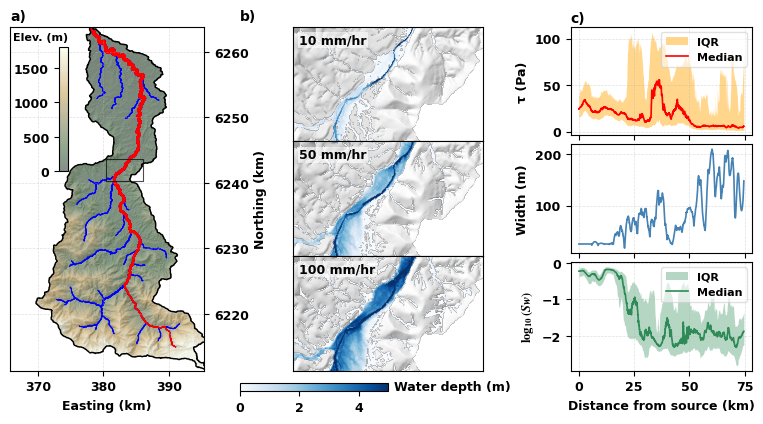

In [29]:
# Zoom bounding box for the inundation panel
xlimz = (np.float64(380455.8180406211), np.float64(386025.55349035654))
ylimz = (np.float64(6240202.807724114), np.float64(6243568.522009828))
xmin, xmax = xlimz
ymin, ymax = ylimz
xrect = [xmin, xmax, xmax, xmin, xmin]
yrect = [ymin, ymin, ymax, ymax, ymin]

# --- Layout ---
fig = plt.figure(figsize=(8, 4.0))
gs_main = GridSpec(1, 3, figure=fig,
                   width_ratios=[1.2, 1.8, 1.1],
                   left=0.04, right=0.97, top=0.96, bottom=0.10,
                   wspace=0.15)
ax_dem   = fig.add_subplot(gs_main[0])
ax_inund = fig.add_subplot(gs_main[1])
gs_right = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs_main[2], hspace=0.08)
ax_tau = fig.add_subplot(gs_right[0])
ax_w   = fig.add_subplot(gs_right[1], sharex=ax_tau)
ax_sw  = fig.add_subplot(gs_right[2], sharex=ax_tau)

# --- Panel a: DEM overview ---
mask_dem = ~np.isnan(dem.z)

ax_dem.imshow(dem.hillshade().z, cmap='gray', extent=dem.extent)
im_dem = ax_dem.imshow(dem.z, cmap=mcolors.ListedColormap(cmocean.cm.topo(np.linspace(0.5, 1.0, 100))), alpha=0.5, vmin=0, vmax=1800, extent=dem.extent)
ax_dem.contour(mask_dem[::-1], levels=[0.5], colors='black', linewidths=1.0, extent=dem.extent)
ax_dem.scatter(xriv, yriv,
    c='b', s=(Ariv - Ariv.min()) / (Ariv.max() - Ariv.min()) * 5 + 0.5, lw=0)
Ariv_trunk = drainage_area[stob_trunk.source_indices]
ax_dem.scatter(xriv_trunk, yriv_trunk,
    c='r', s=(Ariv_trunk - Ariv.min()) / (Ariv.max() - Ariv.min()) * 5 + 0.5, lw=0)
ax_dem.plot(xrect, yrect, lw=0.8, alpha=0.7, color='k')

# Colorbar placed in the nodata space at the top-left of the DEM panel
cax_dem = ax_dem.inset_axes([0.25, 0.58, 0.05, 0.36])
cbar_dem = fig.colorbar(im_dem, cax=cax_dem)
cbar_dem.ax.set_title('Elev. (m)', fontsize=8, pad=5, loc='right')
cax_dem.yaxis.set_ticks_position('left')

km_formatter = FuncFormatter(lambda x, pos: f'{x/1000:.0f}')
ax_dem.xaxis.set_major_formatter(km_formatter)
ax_dem.yaxis.set_major_formatter(km_formatter)
ax_dem.grid(ls='--', alpha=0.4, lw=0.5)
ax_dem.set_xlabel('Easting (km)')
ax_dem.set_ylabel('Northing (km)')
ax_dem.yaxis.set_label_position('right')
ax_dem.yaxis.tick_right()
ax_dem.text(0, 1.01, 'a)', transform=ax_dem.transAxes, va='bottom', ha='left', fontweight='bold')

# --- Panel b: Inundation maps ---
hw_norm = mcolors.Normalize(vmin=0, vmax=5)
hw_cmap = cm.Blues
labels  = ['10 mm/hr', '50 mm/hr', '100 mm/hr']

ax_inund.axis('off')
for k in range(3):
    ins = ax_inund.inset_axes([0.0, (2 - k) / 3, 1.0, 1 / 3])
    ins.imshow(dem.hillshade().z, cmap='gray', extent=dem.extent)
    thw = res[k]['hw'].copy()
    thw[thw < 0.01] = np.nan
    ins.imshow(thw, cmap=hw_cmap, norm=hw_norm, extent=dem.extent, interpolation=None)
    ins.set_xlim(xlimz)
    ins.set_ylim(ylimz)
    ins.set_xticks([])
    ins.set_yticks([])
    ins.text(0.03, 0.94, labels[k], transform=ins.transAxes,
             va='top', fontsize=9, fontweight='bold', color='k',
             bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

cax_inund = ax_inund.inset_axes([0.0, -0.06, 0.5, 0.025])
sm = cm.ScalarMappable(cmap=hw_cmap, norm=hw_norm)
sm.set_array([])
cbar_inund = fig.colorbar(sm, cax=cax_inund, orientation='horizontal')
cax_inund.text(1.04, 0.5, 'Water depth (m)', transform=cax_inund.transAxes,
               va='center', ha='left', fontsize=9)
ax_inund.text(0, 1.01, 'b)', transform=ax_inund.transAxes, va='bottom', ha='left', fontweight='bold')

# --- Panel c1: Shear-stress swath ---
ax_tau.fill_between(d_swath_km, l_swath.q1, l_swath.q3,
    lw=0, color='orange', alpha=0.45, label='IQR')
ax_tau.plot(d_swath_km, l_swath.medians, lw=1.2, color='r', label='Median')
ax_tau.grid(ls='--', alpha=0.4, lw=0.5)
ax_tau.set_ylabel('τ (Pa)')
ax_tau.legend(fontsize=8, loc='upper right', framealpha=0.6)
ax_tau.text(0, 1.01, 'c)', transform=ax_tau.transAxes, va='bottom', ha='left', fontweight='bold')
plt.setp(ax_tau.get_xticklabels(), visible=False)

# --- Panel c2: Channel width ---
ax_w.plot(d_trunk_km, wriv, lw=1.2, color='steelblue')
ax_w.grid(ls='--', alpha=0.4, lw=0.5)
ax_w.set_ylabel('Width (m)')
plt.setp(ax_w.get_xticklabels(), visible=False)

# --- Panel c3: Water-surface slope swath ---
sw_q1 = sw_swath.percentiles[25]
sw_q3 = sw_swath.percentiles[75]
ax_sw.fill_between(d_sw_swath_km,
    np.log10(np.maximum(sw_q1, 1e-6)),
    np.log10(np.maximum(sw_q3, 1e-6)),
    lw=0, color='seagreen', alpha=0.35, label='IQR')
ax_sw.plot(d_sw_swath_km, np.log10(np.maximum(sw_swath.medians, 1e-6)),
    lw=1.2, color='seagreen', label='Median')
ax_sw.grid(ls='--', alpha=0.4, lw=0.5)
ax_sw.set_ylabel(r'$\log_{10}(Sw)$')
ax_sw.set_xlabel('Distance from source (km)')
ax_sw.legend(fontsize=8, loc='upper right', framealpha=0.6)

plt.show()